# Activation Functions and Loss Functions

## 1. Activation Functions

Without activation functions, a neural network of any depth collapses mathematically into a single linear transformation ($W_3(W_2(W_1 X)) = W_{combined} X$). Activations introduce the **non-linearity** needed to model complex real-world data.

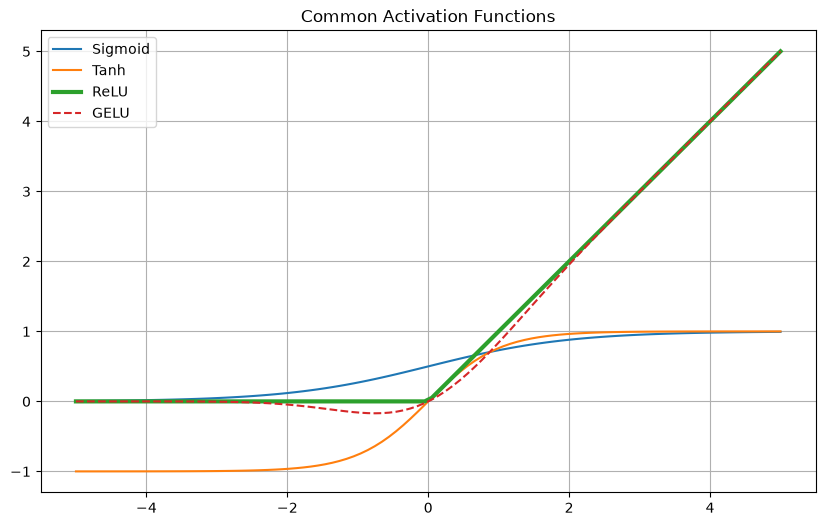

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

x = torch.linspace(-5, 5, 100)

# 1. Sigmoid: Squishes values between 0 and 1. 
# Bad for hidden layers (vanishing gradients), good for binary classification output.
sigmoid = nn.Sigmoid()(x)

# 2. Tanh: Squishes values between -1 and 1. Zero-centered, better than sigmoid.
tanh = nn.Tanh()(x)

# 3. ReLU (Rectified Linear Unit): max(0, x). 
# The industry standard for hidden layers. Fast to compute, no vanishing gradients for positive x.
# Problem: "Dead ReLUs" if x is negative (gradient is 0, neuron stops learning).
relu = nn.ReLU()(x)

# 4. GELU (Gaussian Error Linear Unit): A smoother version of ReLU.
# The standard used in Transformers (GPT, BERT).
gelu = nn.GELU()(x)

plt.figure(figsize=(10, 6))
plt.plot(x, sigmoid, label='Sigmoid')
plt.plot(x, tanh, label='Tanh')
plt.plot(x, relu, label='ReLU', linewidth=3)
plt.plot(x, gelu, label='GELU', linestyle='--')
plt.legend()
plt.title("Common Activation Functions")
plt.grid(True)
# plt.show()

## 2. Loss Functions

The loss function measures how "wrong" the network is. You must choose the right loss function for your specific problem.

In [2]:
# 1. Regression (Predicting a number) -> Mean Squared Error (MSE)
mse_loss = nn.MSELoss()
y_pred_reg = torch.tensor([2.5, 5.1])
y_true_reg = torch.tensor([3.0, 5.0])
print(f"MSE Loss: {mse_loss(y_pred_reg, y_true_reg):.4f}")

# 2. Binary Classification (Dog vs Cat) -> Binary Cross Entropy (BCE)
# Model outputs a single probability between 0 and 1
bce_loss = nn.BCELoss()
y_pred_bin = torch.tensor([0.9, 0.2]) # 90% sure it's class 1, 20% sure it's class 1
y_true_bin = torch.tensor([1.0, 0.0]) # Actually class 1, Actually class 0
print(f"BCE Loss: {bce_loss(y_pred_bin, y_true_bin):.4f}")

# 3. Multi-class Classification (Dog vs Cat vs Bird) -> Cross Entropy
# Note: PyTorch's CrossEntropyLoss AUTOMATICALLY applies Softmax internally!
# You should output raw logits (numbers like [-1.2, 3.4, 0.1]), not probabilities.
ce_loss = nn.CrossEntropyLoss()
# 2 samples, 3 classes. Logits for sample 1 heavily favor class index 1.
logits = torch.tensor([[ -1.2, 3.4, 0.1], 
                       [ 2.0, -0.5, 1.1]]) 
# The actual correct classes (indices)
targets = torch.tensor([1, 0]) 

print(f"Cross Entropy Loss: {ce_loss(logits, targets):.4f}")

MSE Loss: 0.1300
BCE Loss: 0.1643
Cross Entropy Loss: 0.2219


---
## References
*   [PyTorch: nn.Modules (Activations)](https://pytorch.org/docs/stable/nn.html#non-linear-activations-weighted-sum-nonlinearity)
*   [Machine Learning Mastery: How to Choose Loss Functions](https://machinelearningmastery.com/how-to-choose-loss-functions-when-training-deep-learning-neural-networks/)